# <span style="color:darkblue"> QTM 151 Final Project: Time Analysis </span>

# <span style="color:darkblue"> I. Team Members </span>

In [2]:
print("Grace Chen, Matthew Dang, Lynne Zheng")

Grace Chen, Matthew Dang, Lynne Zheng


# <span style="color:darkblue"> II. Introduction </span>

<font size = "4">
Formula 1, or also known as F1, is the world's most popular motorsport racing circuit. The best drivers around the world sign with teams to compete, all with their own special cars and pit crews to give them a competitive edge. In order to get a better understanding of race times in F1, we decided to do our project on Time Analysis Tables. There are many variables that correlate to times, such as pit stop durations, time trends over different race events, and how times have improved over time due to technology and the sharpening of driver skill. 

<font size = "4">
Our final project will mainly answer two questions:<br>

- **Question 1**: Have lap times improved significantly over the years?<br>

- **Question 2**: Are pit stop durations correlated with race outcomes?

# <span style="color:darkblue"> III. Data Description </span>

<font size = "5">
Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os

<font size = "5">
Import Data

In [5]:
races = pd.read_csv("data_raw/races.csv")
results = pd.read_csv("data_raw/results.csv")
lap_times = pd.read_csv("data_raw/lap_times.csv")
pit_stops = pd.read_csv("data_raw/pit_stops.csv")

<font size = "5">
Data Overview

<font size = "4">

We selected three tables to perform the analysis, which include ```races```, ```lap_times```, and ```pit_stops```. 

Some Important rows we will be looking into are: <br>
- ```races```
    1. ```[raceId]```: Identify each 




<font size = "5">

***Question 1*** : Have lap times improved significantly over the years?

<font size = "4">

- Data Merging Pt.1

We will only use the first place in these races to represent the best performance in that year, so filter out the winners first using ```.query()```.

Next, we select the useful columns ```raceId``` ,  ```driverId```, ```milliseconds```, and ```laps```.

In [ ]:
# Data Merging
results_winners = results.query("positionOrder == 1")
results_winners = results_winners[['raceId', 'driverId','milliseconds','laps']]


<font size = "4">

- Data Cleaning

First, we need to check the data types of each variables in order to guarantee further calcuation.

After finding out the column that may include String values, we need to replace the String ```\\N``` with ```np.nan``` and convert the whole column to numeric values using ```pd.to_numeric```.

Now we are able to get the average time used to complete one lap for each winner. 

In [26]:
# Data Cleaning
# 1. Check Data Types
print(results_winners.dtypes)

# 2. Convert milliseconds to numeric
list_replaced = ['\\N']
list_new = [np.nan]
results_winners["milliseconds"] = results_winners["milliseconds"].replace(list_replaced, list_new)
results_winners["milliseconds"] = pd.to_numeric(results_winners["milliseconds"])

#3. Add new columns
results_winners['avg_milliseconds_per_lap'] = results_winners['milliseconds'] / results_winners['laps']
results_winners['avg_seconds_per_lap'] = round(results_winners['avg_milliseconds_per_lap'] / 1000, 2)


raceId                        int64
driverId                      int64
milliseconds                  int64
laps                          int64
avg_milliseconds_per_lap    float64
dtype: object


<font size = "4">

- Data Merging Pt.2

In the second part of merging data, we merge ```races``` and ```results_winners``` to match the winners' time per lap with the year of the race.

There might be several races in a year, and each race has its unique features, so in order to see the overall trend of speed improvements, we will not ignore any of the data.

This new dataset will be sorted by ```year``` in an ascending order for better visualization purpose later. 

In [38]:
# Data Merging 
races_year = races[['raceId','year']]
winners_year_merged = pd.merge(races_year, 
                               results_winners, 
                               on='raceId', 
                               how='left').sort_values(by='year', ascending=True)
winners_year_merged


,raceId,year,driverId,milliseconds,laps,avg_milliseconds_per_lap,avg_seconds_per_lap
841,839,1950,642.0,10277400.0,80.0,128467.500000,128.47
840,838,1950,579.0,10672800.0,64.0,166762.500000,166.76
839,837,1950,579.0,10046000.0,35.0,287028.571429,287.03
838,836,1950,642.0,7373700.0,42.0,175564.285714,175.56
837,835,1950,593.0,10015970.0,138.0,72579.492754,72.58
...,...,...,...,...,...,...,...
1083,1099,2023,NaN,NaN,NaN,NaN,NaN
1082,1098,2023,NaN,NaN,NaN,NaN,NaN
1103,1119,2023,NaN,NaN,NaN,NaN,NaN
1092,1108,2023,NaN,NaN,NaN,NaN,NaN


<font size = "5">

***Question 2***: Are pit stop durations correlated with race outcomes?

# <span style="color:darkblue"> IV. Results </span>

<font size = "5">

***Question 1***: Have lap times improved significantly over the years?

<font size = "4">

To answer this question, we will visualize the trend of lap time changes using a scatterplot. 

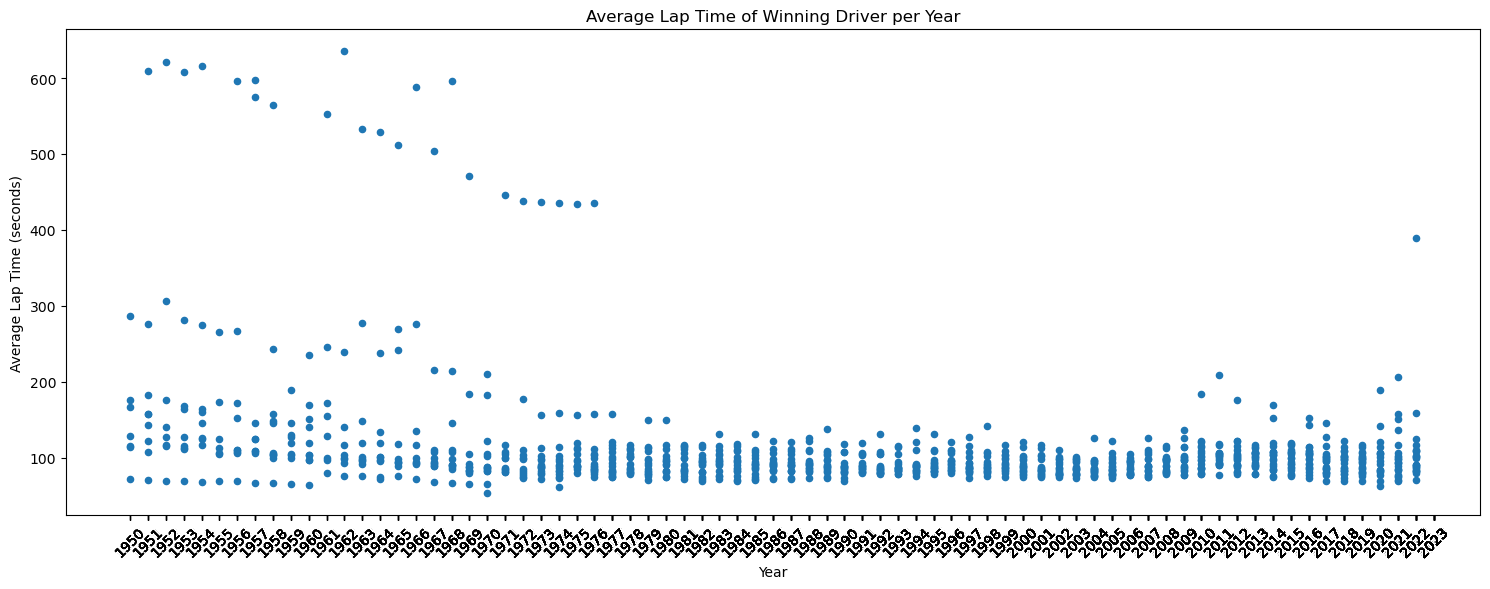

In [ ]:
# Data Visualization

plt.figure(figsize=(15, 6))
plt.scatter(
    x=winners_year_merged['year'], 
    y=winners_year_merged['avg_seconds_per_lap'],
    s=20
)
plt.title('Average Lap Time of Winning Driver per Year')
plt.xlabel('Year')
plt.ylabel('Average Lap Time (seconds)')
plt.xticks(winners_year_merged['year'], rotation=45)
plt.tight_layout() 
plt.show()

<font size = "4">

The plot demonstrates a clear trend of improvement in lap times over the years.


# <span style="color:darkblue"> V. Discussion </span>

<font size = "5">

***Question 1***: Have lap times improved significantly over the years?


<font size = "4">
In the earlier decades, particularly during the 1950s and 1960s, the average lap times of winning drivers were substantially higher, often exceeding 300 seconds per lap, with some instances surpassing 600 seconds. 

However, as the years progressed, a notable decline in lap times is evident. From the 1980s onward, most winning lap times have clustered around 100 seconds, indicating significant gains in speed and efficiency. Although a few outliers remain, the overall downward trend suggests that advancements in automotive technology, improvements in track design, enhanced driver training, and stricter safety standards have collectively contributed to faster race performances. 

This consistent reduction in lap times highlights the ongoing evolution and optimization within motorsport over the past several decades.